## IMPORTS & LOAD DATASET

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
import joblib

In [2]:
df = pd.read_csv("Telecom Customer Churn Dataset.csv")

## DATA CLEANING & Manipulation

In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
(df['TotalCharges'] == " ").sum()

np.int64(11)

In [9]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", None)

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [13]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [14]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [15]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("------")

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
------
gender
['Female' 'Male']
------
SeniorCitizen
[0 1]
------
Partner
['Yes' 'No']
------
Dependents
['No' 'Yes']
------
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
------
PhoneService
['No' 'Yes']
------
MultipleLines
['No phone service' 'No' 'Yes']
------
InternetService
['DSL' 'Fiber optic' 'No']
------
OnlineSecurity
['No' 'Yes' 'No internet service']
------
OnlineBackup
['Yes' 'No' 'No internet service']
------
DeviceProtection
['No' 'Yes' 'No internet service']
------
TechSupport
['No' 'Yes' 'No internet service']
------
StreamingTV
['No' 'Yes' 'No internet service']
------
StreamingMovies
['No' 'Yes' 'No internet service']
------
Contract
['Month-to-month' 'One year' 'Two year']
------
PaperlessBi

In [16]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: "No", 1: "Yes"})

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].str.strip().ne(df[col]).sum())

customerID 0
gender 0
SeniorCitizen 0
Partner 0
Dependents 0
PhoneService 0
MultipleLines 0
InternetService 0
OnlineSecurity 0
OnlineBackup 0
DeviceProtection 0
TechSupport 0
StreamingTV 0
StreamingMovies 0
Contract 0
PaperlessBilling 0
PaymentMethod 0
Churn 0


## EDA & Visualization

In [19]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [20]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [21]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [22]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [23]:
df['TotalCharges'].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [24]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [25]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [26]:
df.groupby('Churn')['TotalCharges'].mean()

Churn
No     2549.911442
Yes    1531.796094
Name: TotalCharges, dtype: float64

In [27]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [28]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [29]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [30]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


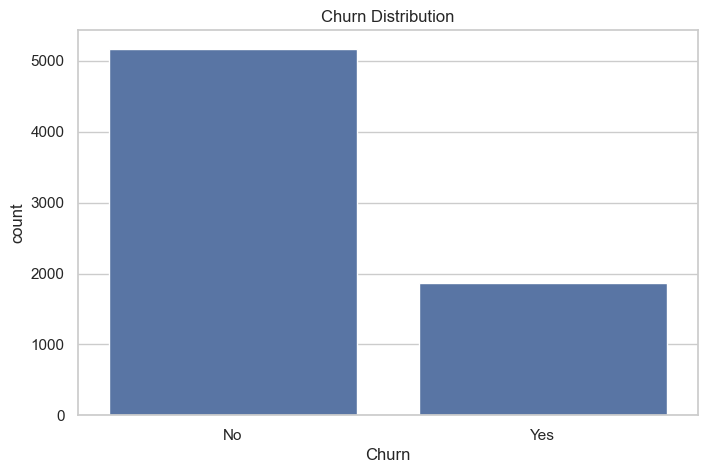

In [31]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

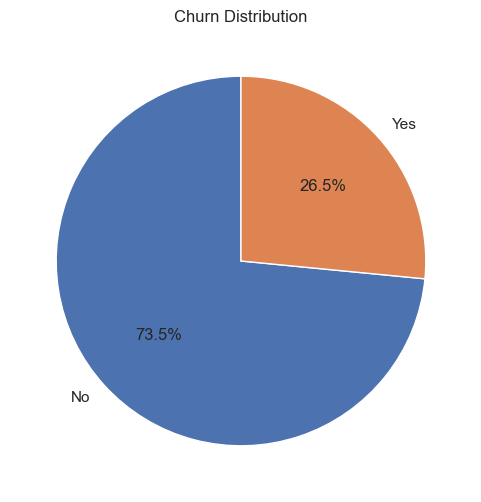

In [32]:
plt.figure(figsize=(6,6))

df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Churn Distribution")
plt.ylabel('')  
plt.show()

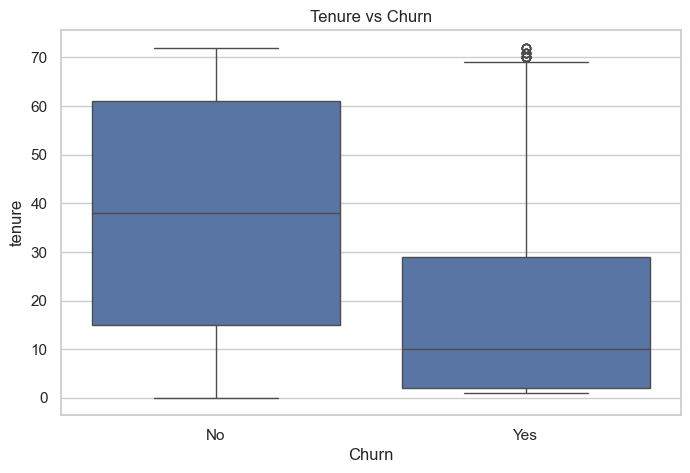

In [33]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

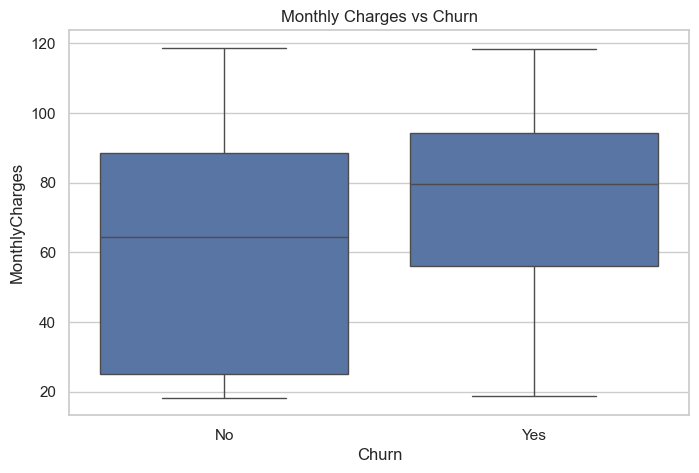

In [34]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

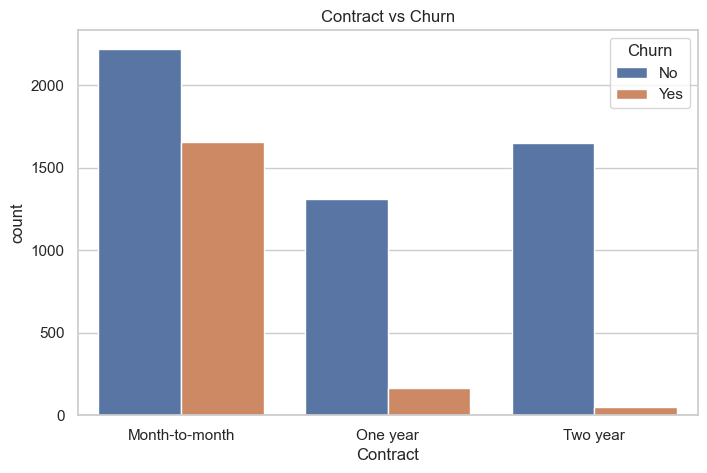

In [35]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract vs Churn")
plt.show()

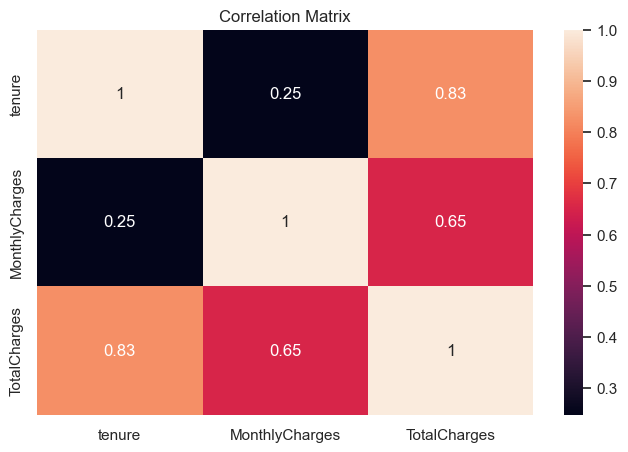

In [36]:
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [37]:
pd.crosstab(
    [df['Contract'], pd.cut(df['tenure'], bins=[0,12,24,48,72])],
    df['Churn'],
    normalize='index'
) * 100

Churn                            No        Yes
Contract       tenure                         
Month-to-month (0, 12]    48.645938  51.354062
               (12, 24]   62.279512  37.720488
               (24, 48]   67.082294  32.917706
               (48, 72]   73.976608  26.023392
One year       (0, 12]    89.430894  10.569106
               (12, 24]   91.878173   8.121827
               (24, 48]   89.382239  10.617761
               (48, 72]   87.066246  12.933754
Two year       (0, 12]   100.000000   0.000000
               (12, 24]  100.000000   0.000000
               (24, 48]   97.810219   2.189781
               (48, 72]   96.674584   3.325416

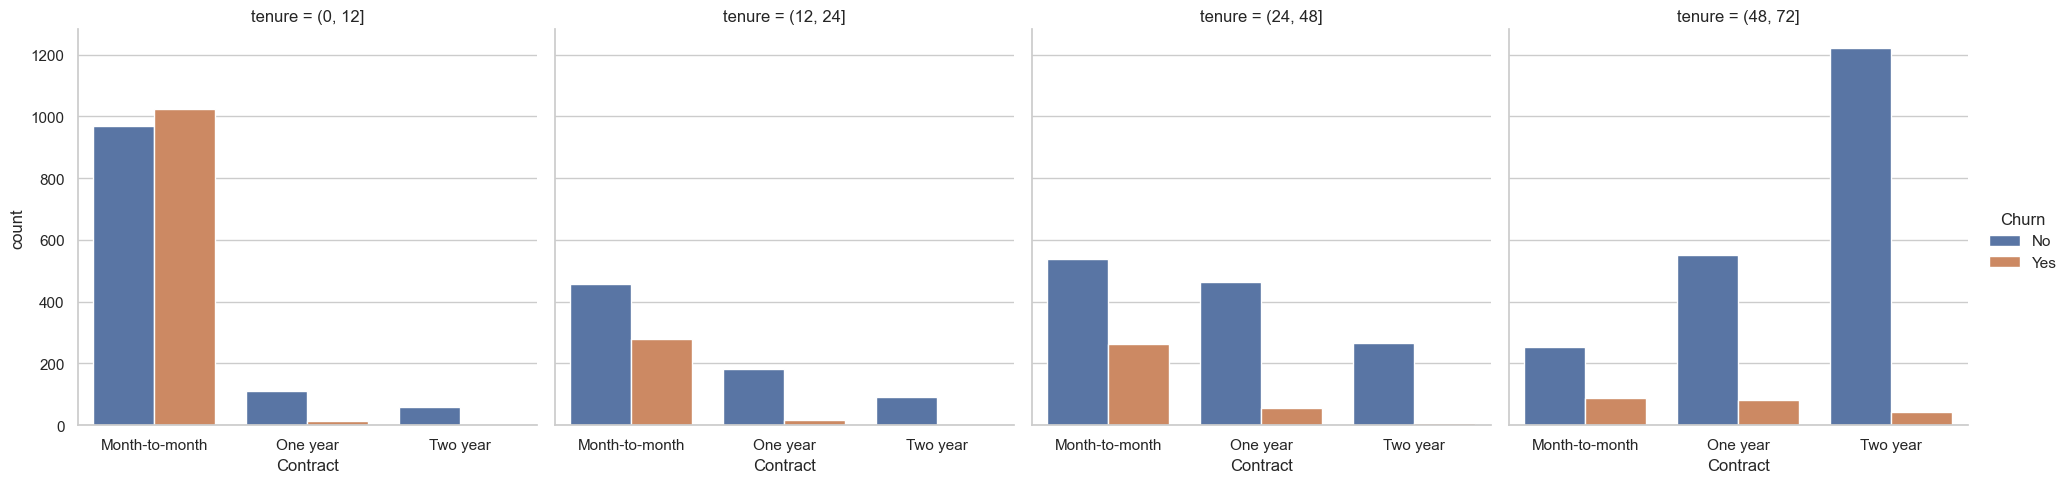

In [38]:
sns.catplot(
    x="Contract",
    hue="Churn",
    col=pd.cut(df['tenure'], bins=[0,12,24,48,72]),
    data=df,
    kind="count"
)

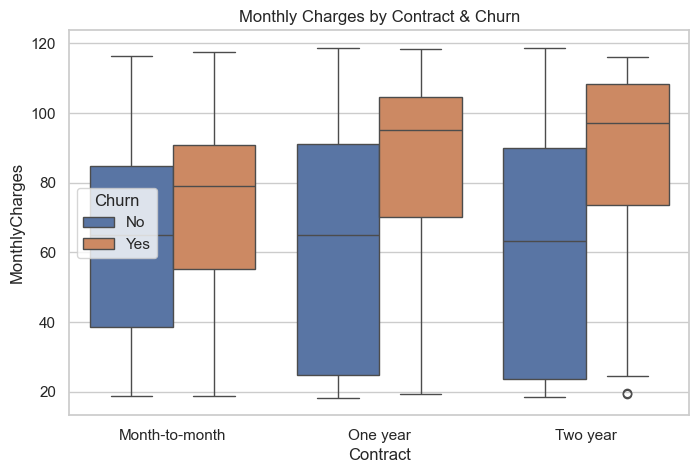

In [39]:
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df)
plt.title("Monthly Charges by Contract & Churn")
plt.show()

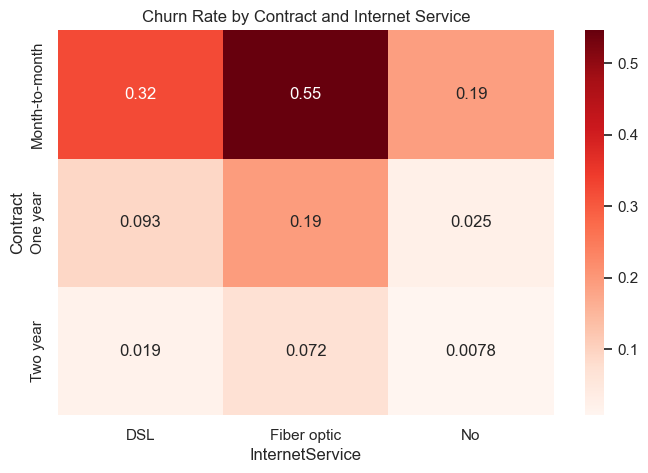

In [40]:
churn_heatmap = pd.crosstab(
    df['Contract'],
    df['InternetService'],
    values=(df['Churn'] == 'Yes'),
    aggfunc='mean'
)

sns.heatmap(churn_heatmap, annot=True, cmap='Reds')

plt.title("Churn Rate by Contract and Internet Service")
plt.show()

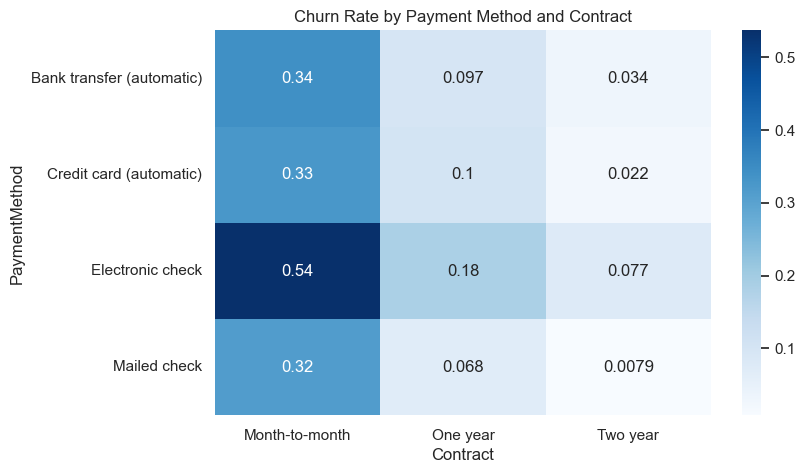

In [41]:
payment_contract = pd.crosstab(
    df['PaymentMethod'],
    df['Contract'],
    values=(df['Churn'] == 'Yes'),
    aggfunc='mean'
)

sns.heatmap(payment_contract, annot=True, cmap='Blues')

plt.title("Churn Rate by Payment Method and Contract")
plt.show()

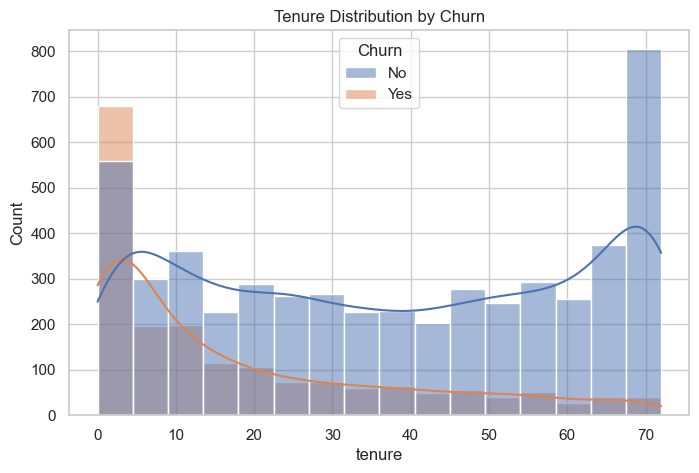

In [42]:
sns.histplot(data=df, x='tenure', hue='Churn', kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()

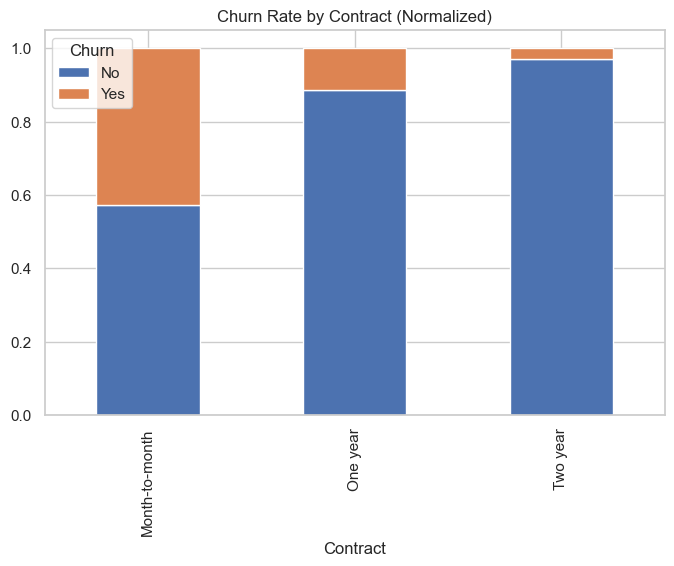

In [43]:
churn_rate = pd.crosstab(df['Contract'], df['Churn'], normalize='index')

churn_rate.plot(kind='bar', stacked=True)
plt.title("Churn Rate by Contract (Normalized)")
plt.show()

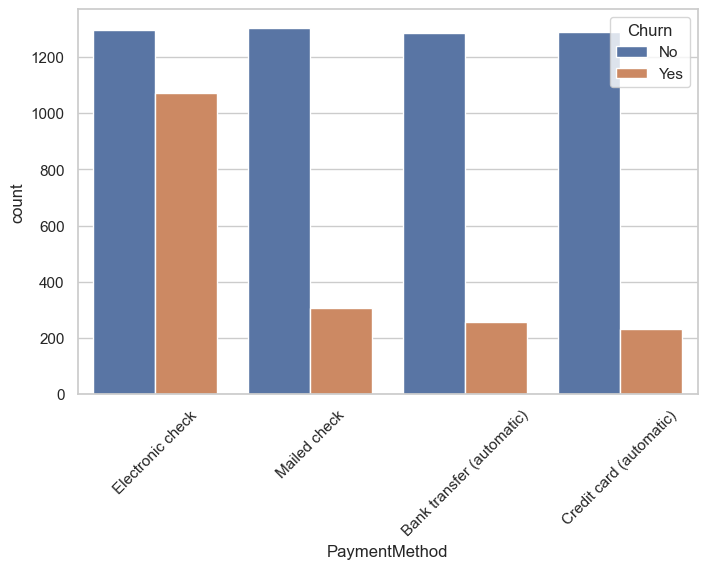

In [44]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

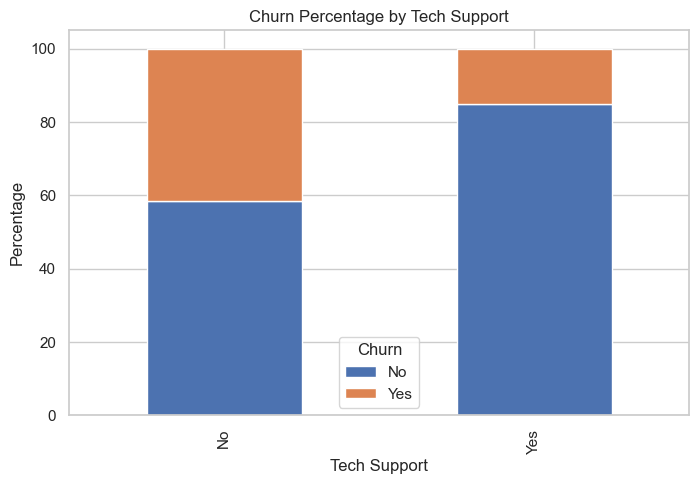

In [45]:
techsupport_churn = pd.crosstab(
    df[df['TechSupport'] != 'No internet service']['TechSupport'],
    df[df['TechSupport'] != 'No internet service']['Churn'],
    normalize='index'
) * 100

techsupport_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Churn Percentage by Tech Support')

plt.xlabel('Tech Support')

plt.ylabel('Percentage')

plt.legend(title='Churn')

plt.show()

In [46]:
services = ['PhoneService','MultipleLines','InternetService',
            'OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']

df['NumServices'] = df[services].apply(lambda x: sum(x == 'Yes'), axis=1)

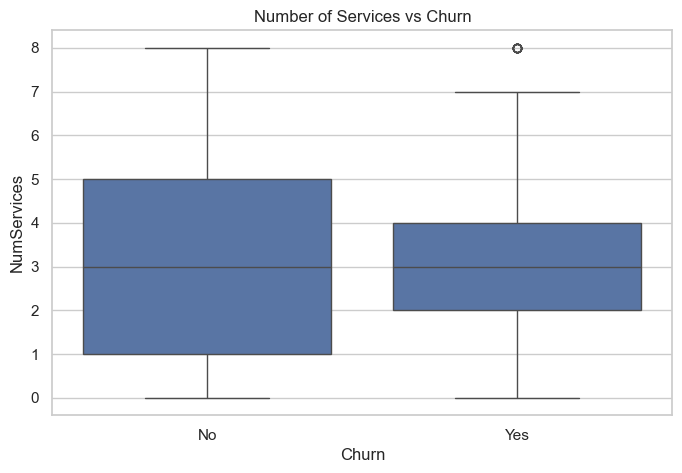

In [47]:
sns.boxplot(x='Churn', y='NumServices', data=df)
plt.title("Number of Services vs Churn")
plt.show()

## Feature Engineering

In [48]:
df['CustomerSegment'] = pd.cut(
    df['tenure'],
    bins=[0,12,36,72],
    labels=['New','Mid','Loyal']
)

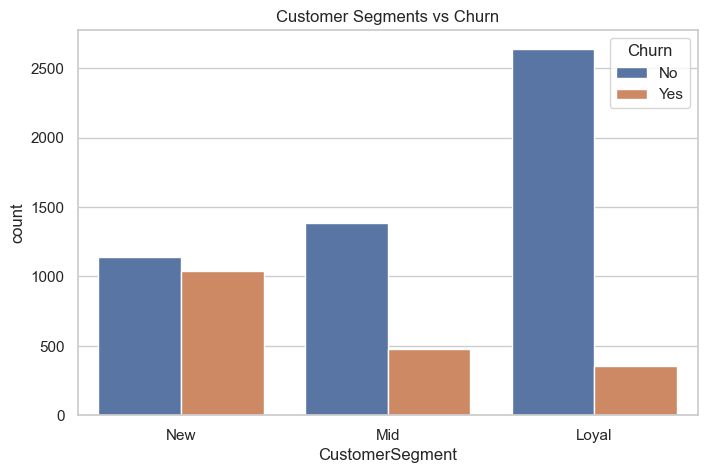

In [49]:
sns.countplot(x='CustomerSegment', hue='Churn', data=df)
plt.title("Customer Segments vs Churn")
plt.show()

In [50]:
df['IsNewCustomer'] = (df['tenure'] < 12).astype(int)

In [51]:
median_charge = df['MonthlyCharges'].median()

df['HighMonthlyCharges'] = (
    df['MonthlyCharges'] > median_charge
).astype(int)

In [52]:
df['HasFiberOptic'] = (
    df['InternetService'] == 'Fiber optic'
).astype(int)

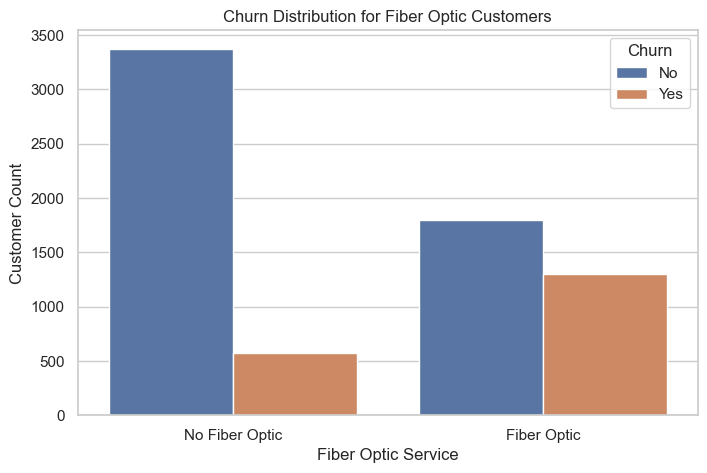

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='HasFiberOptic',
    hue='Churn'
)

plt.xticks(
    [0,1],
    ['No Fiber Optic', 'Fiber Optic']
)

plt.title('Churn Distribution for Fiber Optic Customers')

plt.xlabel('Fiber Optic Service')

plt.ylabel('Customer Count')

plt.legend(title='Churn')

plt.show()

In [54]:
df['LongTermContract'] = (
    df['Contract'] != 'Month-to-month'
).astype(int)

In [55]:
auto_payments = [
    'Bank transfer (automatic)',
    'Credit card (automatic)'
]

df['AutoPayment'] = (
    df['PaymentMethod'].isin(auto_payments)
).astype(int)

In [56]:
df[['IsNewCustomer',
    'HighMonthlyCharges',
    'NumServices',
    'HasFiberOptic',
    'LongTermContract',
    'AutoPayment']].head()

,IsNewCustomer,HighMonthlyCharges,NumServices,HasFiberOptic,LongTermContract,AutoPayment
0,1,0,1,0,0,0
1,0,0,3,0,1,0
2,1,0,3,0,0,0
3,0,0,3,0,1,1
4,1,1,1,1,0,0


## Preprocessing

In [57]:
X = df.drop(columns=['customerID', 'Churn'])

In [58]:
y = df['Churn']

In [59]:
y = y.map({
    'Yes': 1,
    'No': 0
})

In [60]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'NumServices'
]

In [61]:
cat_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'IsNewCustomer',
    'HighMonthlyCharges',
    'HasFiberOptic',
    'LongTermContract',
    'AutoPayment'
]

In [62]:
print(num_cols)
print(cat_cols)

['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'IsNewCustomer', 'HighMonthlyCharges', 'HasFiberOptic', 'LongTermContract', 'AutoPayment']


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [64]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

In [65]:
X_train_processed = preprocessor.fit_transform(X_train)

In [66]:
X_test_processed = preprocessor.transform(X_test)

In [67]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 36)
(1409, 36)


## Modelling & Evaluation

In [68]:
log_model = LogisticRegression(max_iter=1000)

In [69]:
log_model.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [70]:
y_pred = log_model.predict(X_test_processed)

In [71]:
y_prob = log_model.predict_proba(X_test_processed)[:, 1]

In [72]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

In [73]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.8019872249822569
Precision: 0.6588628762541806
Recall: 0.5267379679144385
F1 Score: 0.5854383358098069
ROC-AUC: 0.8413908910072592


In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



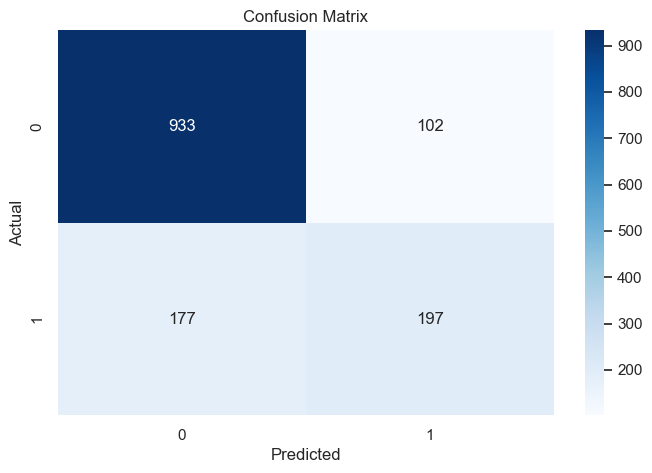

In [75]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [76]:
balanced_log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

In [77]:
balanced_log_model.fit(
    X_train_processed,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [78]:
y_pred_balanced = balanced_log_model.predict(
    X_test_processed
)

In [79]:
y_prob_balanced = balanced_log_model.predict_proba(
    X_test_processed
)[:,1]

In [80]:
print(classification_report(
    y_test,
    y_pred_balanced
))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



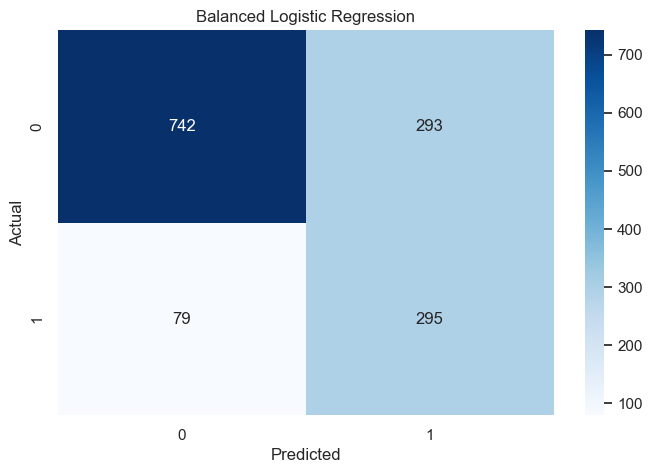

In [81]:
cm = confusion_matrix(
    y_test,
    y_pred_balanced
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Balanced Logistic Regression")

plt.show()

In [82]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

In [83]:
rf_model.fit(X_train_processed, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [84]:
y_pred_rf = rf_model.predict(X_test_processed)

y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

In [85]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.55      0.73      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



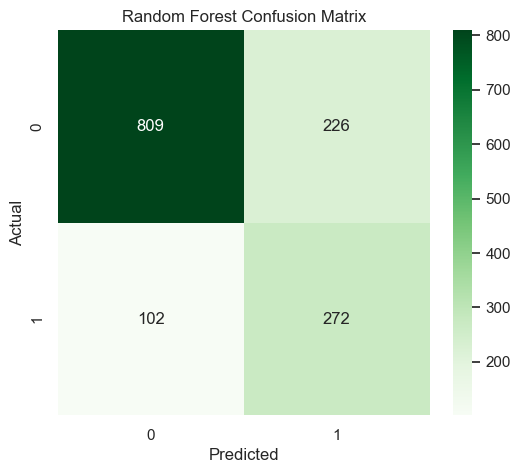

In [86]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [87]:
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC Score:", roc_auc_rf)

ROC-AUC Score: 0.8409904673331784


In [88]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [89]:
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

In [90]:
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

In [91]:
grid_search.fit(X_train_processed, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [92]:
print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}


In [93]:
best_rf = grid_search.best_estimator_

In [94]:
y_pred_best_rf = best_rf.predict(X_test_processed)

y_prob_best_rf = best_rf.predict_proba(X_test_processed)[:, 1]

In [95]:
print(classification_report(
    y_test,
    y_pred_best_rf
))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



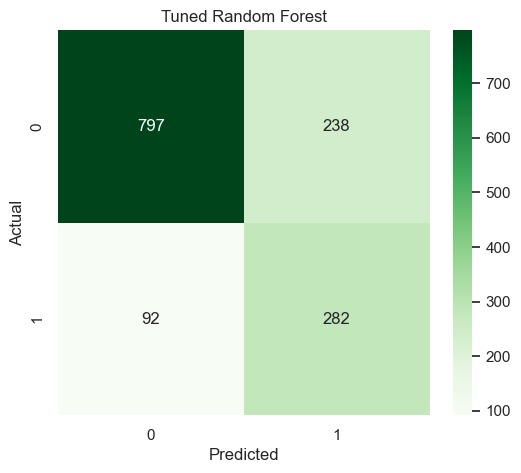

In [96]:
cm_best_rf = confusion_matrix(
    y_test,
    y_pred_best_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_best_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Random Forest")

plt.show()

In [97]:
roc_auc_best_rf = roc_auc_score(
    y_test,
    y_prob_best_rf
)

print("ROC-AUC Score:", roc_auc_best_rf)

ROC-AUC Score: 0.8423635330284946


In [98]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2.7,
    random_state=42,
    eval_metric='logloss'
)

In [99]:
xgb_model.fit(
    X_train_processed,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [100]:
y_pred_xgb = xgb_model.predict(
    X_test_processed
)

y_prob_xgb = xgb_model.predict_proba(
    X_test_processed
)[:,1]

In [101]:
print(classification_report(
    y_test,
    y_pred_xgb
))

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



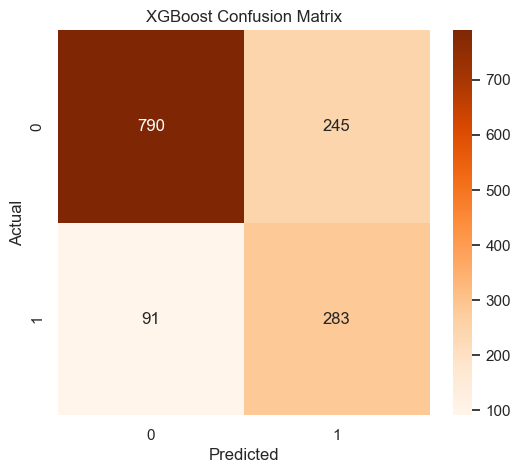

In [102]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [103]:
roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("ROC-AUC Score:", roc_auc_xgb)

ROC-AUC Score: 0.837168358779612


In [104]:
feature_names = preprocessor.get_feature_names_out()

In [105]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
})

In [106]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [107]:
feature_importance.head(15)

,Feature,Importance
34,cat__LongTermContract_1,0.267395
33,cat__HasFiberOptic_1,0.122908
26,cat__Contract_Two year,0.107785
11,cat__InternetService_Fiber optic,0.105305
31,cat__IsNewCustomer_1,0.063194
12,cat__InternetService_No,0.038457
13,cat__OnlineSecurity_No internet service,0.033419
25,cat__Contract_One year,0.023231
24,cat__StreamingMovies_Yes,0.018205
29,cat__PaymentMethod_Electronic check,0.017753


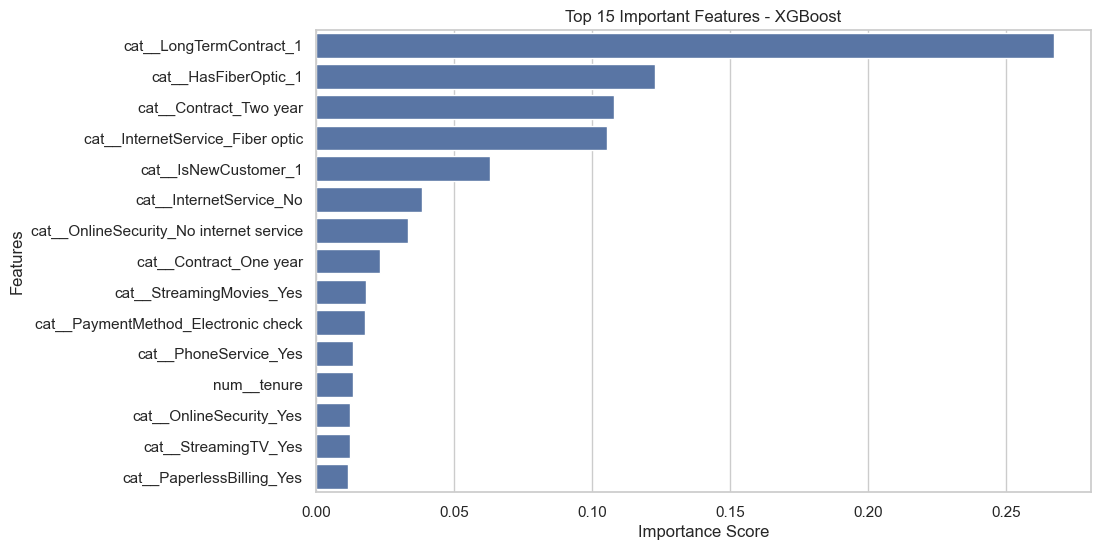

In [108]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features - XGBoost")

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [109]:
models_comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Balanced Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Precision': [

        classification_report(y_test, y_pred, output_dict=True)['1']['precision'],

        classification_report(y_test, y_pred_balanced, output_dict=True)['1']['precision'],

        classification_report(y_test, y_pred_best_rf, output_dict=True)['1']['precision'],

        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['precision']
    ],

    'Recall': [

        classification_report(y_test, y_pred, output_dict=True)['1']['recall'],

        classification_report(y_test, y_pred_balanced, output_dict=True)['1']['recall'],

        classification_report(y_test, y_pred_best_rf, output_dict=True)['1']['recall'],

        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['recall']
    ],

    'F1-Score': [

        classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'],

        classification_report(y_test, y_pred_balanced, output_dict=True)['1']['f1-score'],

        classification_report(y_test, y_pred_best_rf, output_dict=True)['1']['f1-score'],

        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['f1-score']
    ],

    'ROC-AUC': [

        roc_auc_score(y_test, y_prob),

        roc_auc_score(y_test, y_prob_balanced),

        roc_auc_score(y_test, y_prob_best_rf),

        roc_auc_score(y_test, y_prob_xgb)
    ]
})

models_comparison.round(3)

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.659,0.527,0.585,0.841
1,Balanced Logistic Regression,0.502,0.789,0.613,0.841
2,Random Forest,0.542,0.754,0.631,0.842
3,XGBoost,0.536,0.757,0.627,0.837


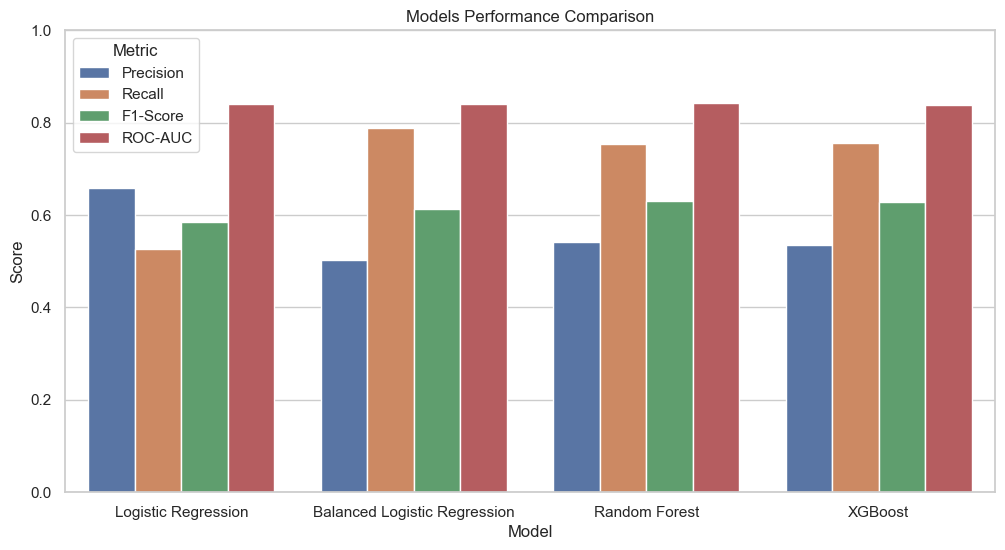

In [110]:
comparison_melted = models_comparison.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_melted,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title("Models Performance Comparison")

plt.ylim(0,1)

plt.show()

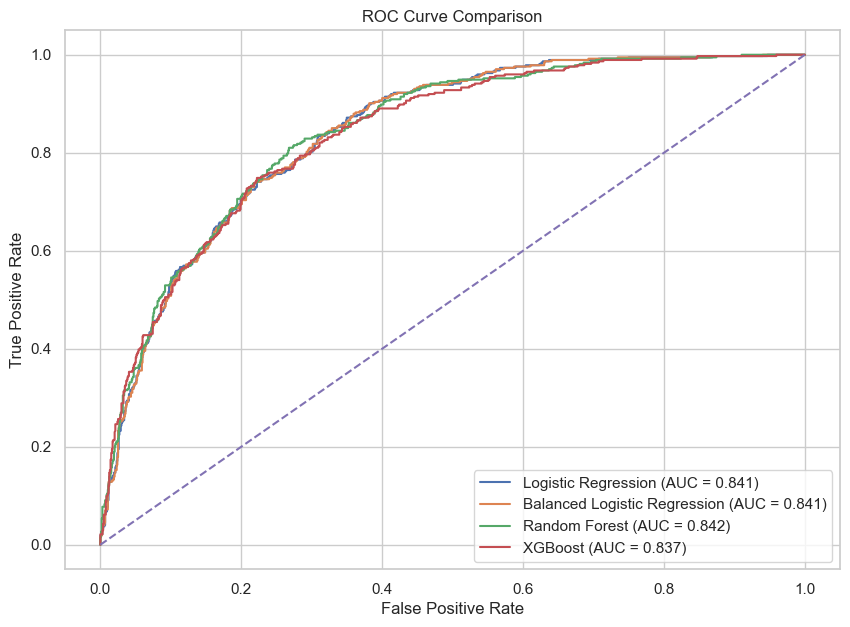

In [111]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)

fpr_balanced, tpr_balanced, _ = roc_curve(y_test, y_prob_balanced)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_best_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(10,7))

plt.plot(fpr_log, tpr_log,
         label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})')

plt.plot(fpr_balanced, tpr_balanced,
         label=f'Balanced Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_balanced):.3f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_best_rf):.3f})')

plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## Model Deployment

In [113]:
joblib.dump(best_rf, 'random_forest_churn_model.pkl')

['random_forest_churn_model.pkl']

In [114]:
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

In [115]:
loaded_model = joblib.load('random_forest_churn_model.pkl')

loaded_preprocessor = joblib.load('preprocessor.pkl')